# Healthcare Project


### 1. Preliminary Analysis

#### Inspect the data:
- Load the data
- Read the shape of the data (rows x columns)
- Column names & Types
- Check if any Missing Values
- Check if any duplicates

In [34]:
# import Library
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [35]:
# Load and Read the data
data = (r"C:\Users\Amir\Dropbox\ibm simpli learn\Data Analyst Capstone\Healthcare\healthcare_dataset\Dataset\data.xlsx")
data = pd.read_excel(data, sheet_name = 'heart')

In [36]:
variable_description = (r"C:\Users\Amir\Dropbox\ibm simpli learn\Data Analyst Capstone\Healthcare\healthcare_dataset\Dataset\variable description.xlsx")
variable_description = pd.read_excel(variable_description, sheet_name = 'Sheet1')
variable_description

,variable,description
0,age,age in years
1,sex,(1 = male; 0 = female)
2,cp,chest pain type
3,trestbps,resting blood pressure (in mm Hg on admission...
4,chol,serum cholestoral in mg/dl
5,fbs,(fasting blood sugar > 120 mg/dl) (1 = true; ...
6,restecg,resting electrocardiographic results
7,thalach,maximum heart rate achieved
8,exang,exercise induced angina (1 = yes; 0 = no)
9,oldpeak,ST depression induced by exercise relative to...


#### Target Variable: heart disease( 0 = no, 1= yes)
Our 'Target Variable' is the diagnosis variable. It is called 'target' in the dataframe. It has two values: 0 means the person is not risky and 1 means the person is diagnosed as heart diseased. In that part, we are going to try what may have an impact on cardiovascular diseases. 

In [37]:
# Information about data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 302 entries, 0 to 301
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       302 non-null    int64  
 1   sex       302 non-null    int64  
 2   cp        302 non-null    int64  
 3   trestbps  302 non-null    int64  
 4   chol      302 non-null    int64  
 5   fbs       302 non-null    int64  
 6   restecg   302 non-null    int64  
 7   thalach   302 non-null    int64  
 8   exang     302 non-null    int64  
 9   oldpeak   302 non-null    float64
 10  slope     302 non-null    int64  
 11  ca        302 non-null    int64  
 12  thal      302 non-null    int64  
 13  target    302 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.2 KB


## Cleaning

In [38]:
# missing values or null values in each column
print(data.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [39]:
# duplicate values
data.columns.duplicated().sum()


np.int64(0)

There are no missing, null values or any duplicates in our dataset.

## Exploring the Data
For better readability and clarity in the analysis, I have renamed several abbreviated columns to more descriptive names as mentioned in the second csv file, named variable_description. This makes the dataset easier to interpret and improves the effectiveness of visualizations and reports

In [40]:
# Rename abbreviated columns to more understandable names
data.rename(columns={
    'age': 'age',
    'sex': 'gender',
    'cp': 'chest_pain_type',
    'trestbps': 'resting_blood_pressure',
    'chol': 'cholesterol',
    'fbs': 'fasting_blood_sugar',
    'restecg': 'resting_ecg',
    'thalach': 'max_heart_rate_achieved',
    'exang': 'exercise_induced_angina',
    'oldpeak': 'st_depression',
    'slope': 'st_slope',
    'ca': 'num_major_vessels',
    'thal': 'thalassemia_type',
    'target': 'heart_attack'
}, inplace=True)


I separate the fields into two categories, numerical features and categorical features. So, it will be much easier to understand the data_type of each column and to use the right method  for analysis and modeling.

In [41]:
cat_features = ['gender', 'chest_pain_type', 'fasting_blood_sugar', 'resting_ecg', 'exercise_induced_angina', 'st_slope', 'num_major_vessels', 'thalassemia_type']
num_features = ['age', 'resting_blood_pressure', 'cholesterol', 'max_heart_rate_achieved', 'st_depression']

## Statistical Summary 

In [42]:
# Converting Numerical Codes to Descriptive Labels and Optimizing Data Types
data['gender'] = data['gender'].map({0:'Female', 1:'Male'})
data['chest_pain_type'] = data['chest_pain_type'].map({0:'Non-anginal Pain',1:'Typical Angina',2:'Atypical Angina',3:'Asymptomatic'})
data['fasting_blood_sugar'] = data['fasting_blood_sugar'].map({0:'lower than 120mg/ml', 1:'greater than 120 mg/ml'})
data['resting_ecg'] = data['resting_ecg'].map({0:'Normal', 1:'ST-T wave abnormality', 2:'Left Ventricular Hypertrophy'})
data['exercise_induced_angina'] = data['exercise_induced_angina'].map({0:'No', 1:'Yes'})
data['st_slope'] = data['st_slope'].map({0:'UPsloping', 1:'Flat', 2:'Down Sloping'})
data['thalassemia_type'] = data['thalassemia_type'].map({0:'None',1:'Normal', 2:'Fixed Defect', 3:'Reversable Defect'})
data['heart_attack'] = data['heart_attack'].map({0:'No', 1:'Yes'})

In [43]:
data.dtypes

age                          int64
gender                      object
chest_pain_type             object
resting_blood_pressure       int64
cholesterol                  int64
fasting_blood_sugar         object
resting_ecg                 object
max_heart_rate_achieved      int64
exercise_induced_angina     object
st_depression              float64
st_slope                    object
num_major_vessels            int64
thalassemia_type            object
heart_attack                object
dtype: object

Initially, some of the categorical columns in the dataset had numeric values (e.g., 0 and 1 for gender). To make the data more understandable, I converted these numeric values into meaningful labels, such as changing 0 to "Female" and 1 to "Male". After performing similar transformations for all categorical columns, the data type of these columns was set to object. To optimize memory usage and improve performance, I then converted these columns to the category data type.

In [44]:
# changing object dtype to category to save memory
data.gender = data['gender'].astype("category")
data.chest_pain_type = data['chest_pain_type'].astype("category")
data.fasting_blood_sugar = data['fasting_blood_sugar'].astype("category")
data.resting_ecg = data['resting_ecg'].astype("category")
data.st_slope = data['st_slope'].astype("category")
data.exercise_induced_angina = data['exercise_induced_angina'].astype("category")
data.thalassemia_type = data['thalassemia_type'].astype("category")
data['heart_attack'] = data['heart_attack'].astype("category")

In [45]:
data.dtypes

age                           int64
gender                     category
chest_pain_type            category
resting_blood_pressure        int64
cholesterol                   int64
fasting_blood_sugar        category
resting_ecg                category
max_heart_rate_achieved       int64
exercise_induced_angina    category
st_depression               float64
st_slope                   category
num_major_vessels             int64
thalassemia_type           category
heart_attack               category
dtype: object

In [46]:
data.describe()

,age,resting_blood_pressure,cholesterol,max_heart_rate_achieved,st_depression,num_major_vessels
count,302.00000,302.000000,302.000000,302.000000,302.000000,302.000000
mean,54.42053,131.602649,246.500000,149.569536,1.043046,0.718543
std,9.04797,17.563394,51.753489,22.903527,1.161452,1.006748
min,29.00000,94.000000,126.000000,71.000000,0.000000,0.000000
25%,48.00000,120.000000,211.000000,133.250000,0.000000,0.000000
50%,55.50000,130.000000,240.500000,152.500000,0.800000,0.000000
75%,61.00000,140.000000,274.750000,166.000000,1.600000,1.000000
max,77.00000,200.000000,564.000000,202.000000,6.200000,4.000000


In [47]:
data.describe(include='category')

,gender,chest_pain_type,fasting_blood_sugar,resting_ecg,exercise_induced_angina,st_slope,thalassemia_type,heart_attack
count,302,302,302,302,302,302,302,302
unique,2,4,2,3,2,3,4,2
top,Male,Non-anginal Pain,lower than 120mg/ml,ST-T wave abnormality,No,Down Sloping,Fixed Defect,Yes
freq,206,143,257,151,203,141,165,164


In [48]:
# The Distribution/Count of Unique Values for each Category Column
list_col = data.select_dtypes(['category']).columns
for i in range(len(list_col)):
    print(data[list_col[i]].value_counts())

gender
Male      206
Female     96
Name: count, dtype: int64
chest_pain_type
Non-anginal Pain    143
Atypical Angina      86
Typical Angina       50
Asymptomatic         23
Name: count, dtype: int64
fasting_blood_sugar
lower than 120mg/ml       257
greater than 120 mg/ml     45
Name: count, dtype: int64
resting_ecg
ST-T wave abnormality           151
Normal                          147
Left Ventricular Hypertrophy      4
Name: count, dtype: int64
exercise_induced_angina
No     203
Yes     99
Name: count, dtype: int64
st_slope
Down Sloping    141
Flat            140
UPsloping        21
Name: count, dtype: int64
thalassemia_type
Fixed Defect         165
Reversable Defect    117
Normal                18
None                   2
Name: count, dtype: int64
heart_attack
Yes    164
No     138
Name: count, dtype: int64


## EDA (Exploratory Data Analysis) on Categorical Features

<function matplotlib.pyplot.show(close=None, block=None)>

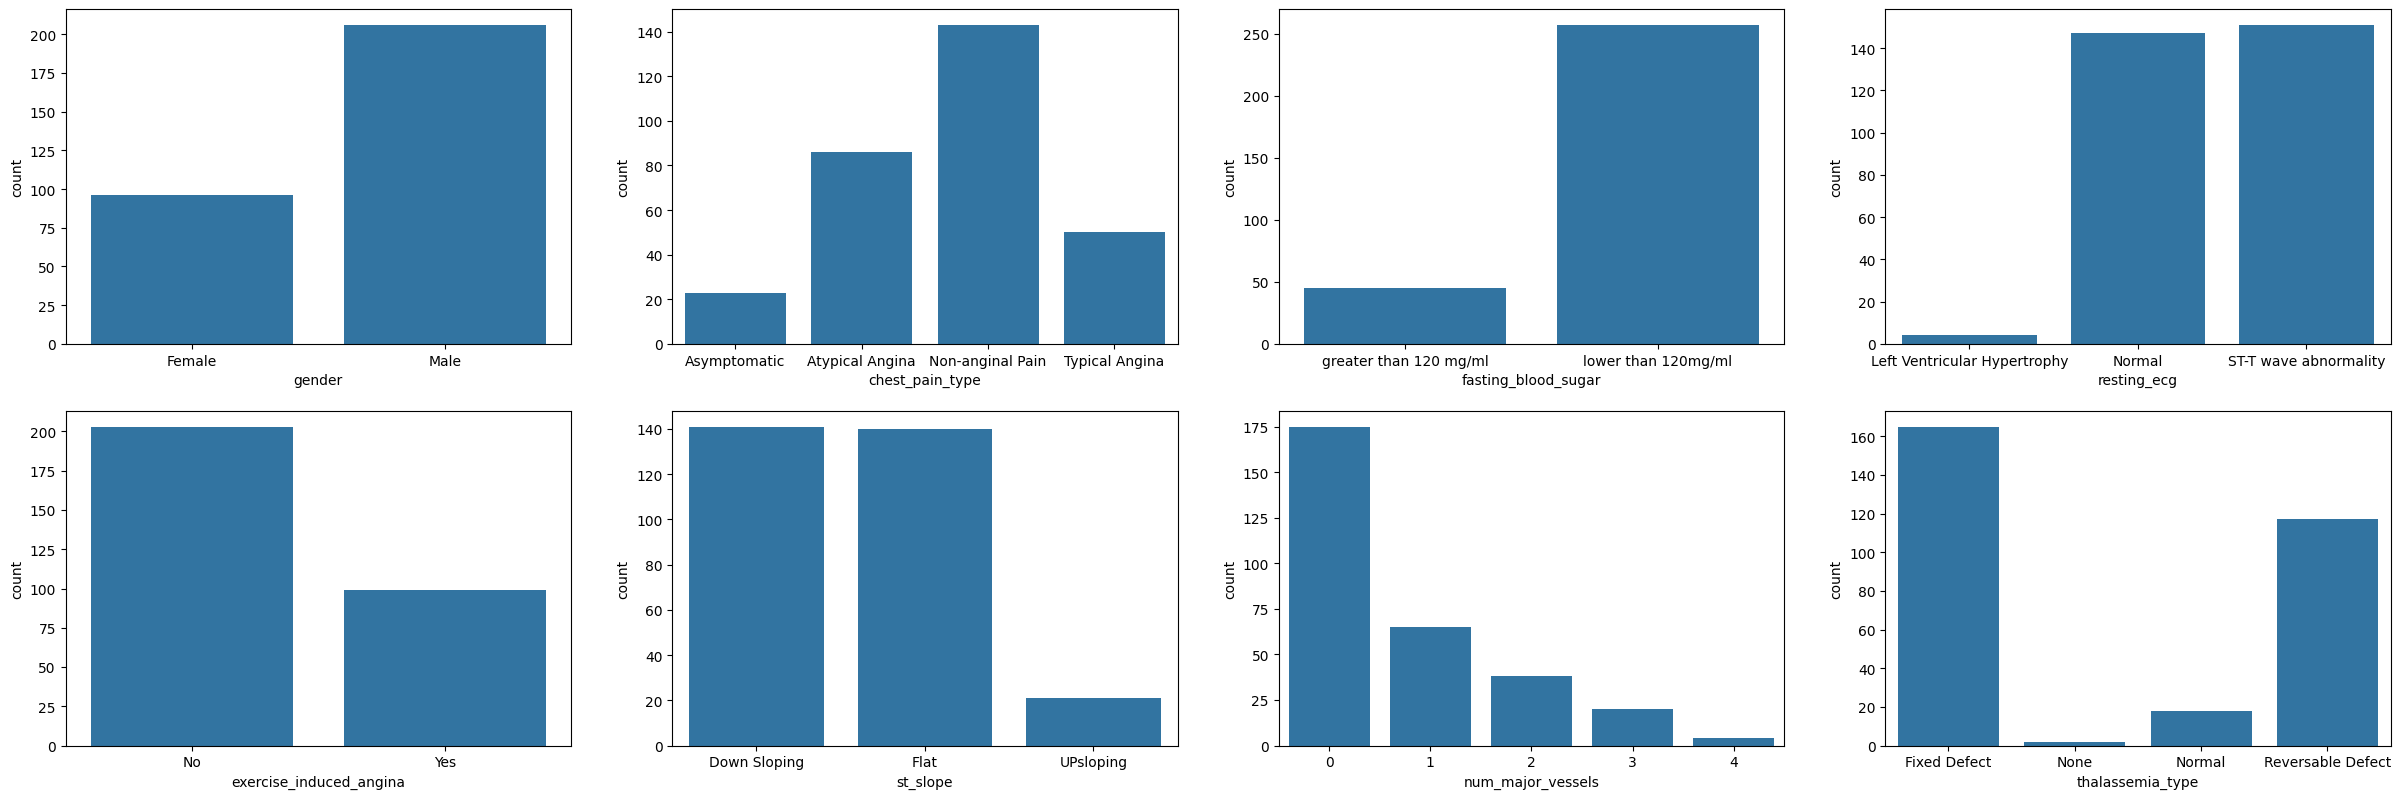

In [49]:
# Identify the data variables which might be categorical in nature. Describe and explore these variables using appropriate tools e.g. count plot
n = 4
plt.figure(figsize=(30,20))
for i, col in enumerate(cat_features):
    plt.subplot(n, n, i+1)
    sns.countplot(x=col, data=data)
plt.show

## EDA on Numerical Features

### c. Occurence of Heart Attack on Ages:
Since we don't have CVD, we can use our actual target variable (likely heart attack indicator).

<Axes: xlabel='age_bin', ylabel='count'>

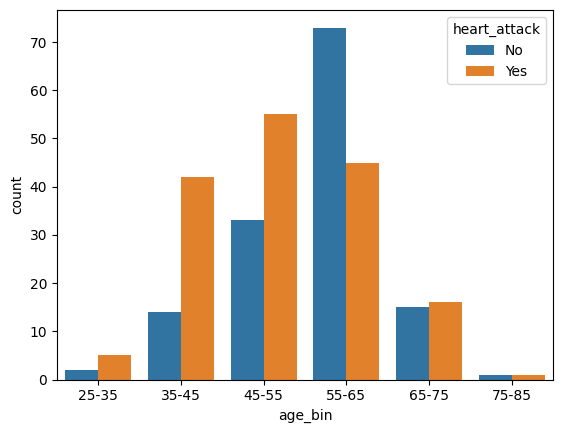

In [50]:
# Binning Age
data['age_bin'] = pd.cut(data['age'], bins =[25, 35, 45, 55, 65, 75, 85], labels=["25-35", "35-45", "45-55", "55-65", "65-75", "75-85"])
sns.countplot(x='age_bin', hue='heart_attack', data=data)

Based on the dataset and bars, it suggest that in this dataset, younger people may be more likely to have had heart attacks — possibly due to other risk factors. This is unexpected as heart issues are more common in older ages, so this result might be influenced by other variables like stress, lifestyle, or sample size.

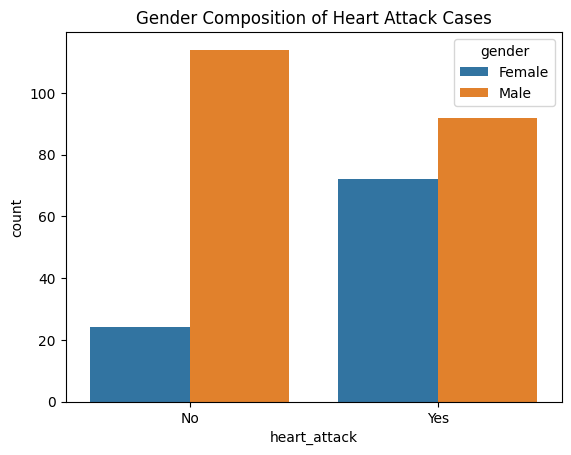

In [51]:
# d. Gender Composition
sns.countplot(x='heart_attack', hue='gender', data=data)
plt.title('Gender Composition of Heart Attack Cases')
plt.show()


In [52]:
# Calculate the proportions of each gender within each heart attack category
gender_heart_attack_composition = pd.crosstab(data['heart_attack'], data['gender'], normalize='index')
print(gender_heart_attack_composition)

gender          Female      Male
heart_attack                    
No            0.173913  0.826087
Yes           0.439024  0.560976


As shown above, the gender distribution is higher for males in both heart attack and non-heart attack cases. It might suggest that males are more common in the dataset, but this doesn’t imply that gender is a determining factor for heart attacks in the dataset. It could indicate that other factors, such as age, lifestyle, or underlying medical conditions, might be stronger predictors of heart attacks than gender alone.

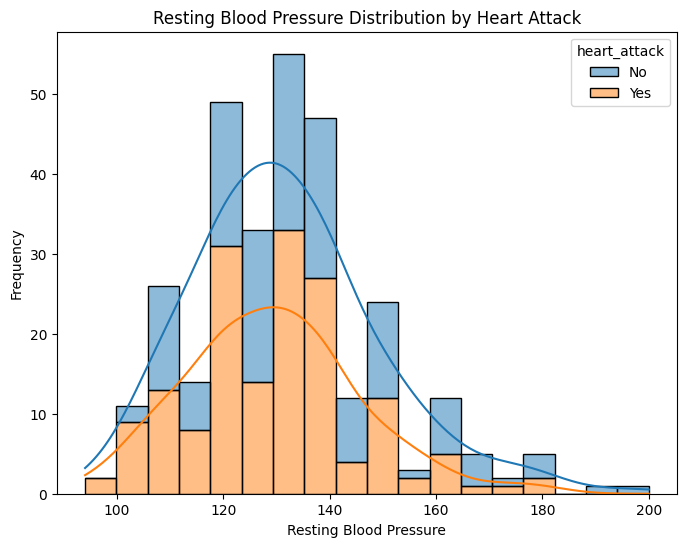

In [53]:
plt.figure(figsize=(8, 6))
sns.histplot(data=data, x='resting_blood_pressure', hue='heart_attack', multiple="stack", kde=True)
plt.title('Resting Blood Pressure Distribution by Heart Attack')
plt.xlabel('Resting Blood Pressure')
plt.ylabel('Frequency')
plt.show()


We notice the peak of two curves, the blue peaks at a higher blood pressure and the orange curve peaks at a lower blood pressure, this is counterintuitive finding, as traditionally, higher blood pressure is considered a risk factor for heart disease.
However, in this case, the higher blood pressure might be influenced by other factors, such as age, smoking, etc.

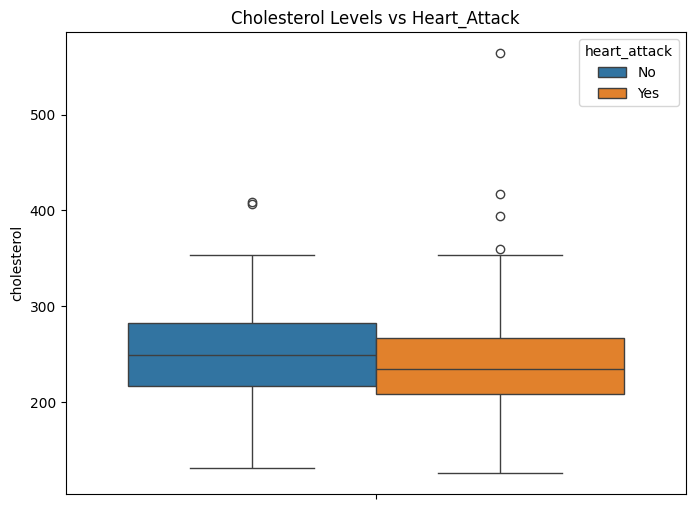

In [54]:
# f. Cholesterol Levels vs Heart Attack
plt.figure(figsize=(8,6))
sns.boxplot(y ='cholesterol',hue='heart_attack',data =data)
plt.title('Cholesterol Levels vs Heart_Attack')
plt.show()

The 4 visible and spread outliers in "Yes" group indicates that some patients had unusually high or low cholesterol levels, suggesting great variablity. However, the size of plot  suggests the patients with "Yes Heart Attack" had similar cholesterol levels.

The concentrated outliers in "No" group indicates a subgroup of patients with high cholesterol but no heart attacks - possibly due to protective factors (e.g., lifestyle, genetics). As plot is wider, the patients with "No Heart Attacks" vary more.

The interpretation suggests that cholesterol feature should be considered as part of a multifactorial risk model rather than an isolated predictor for this case.


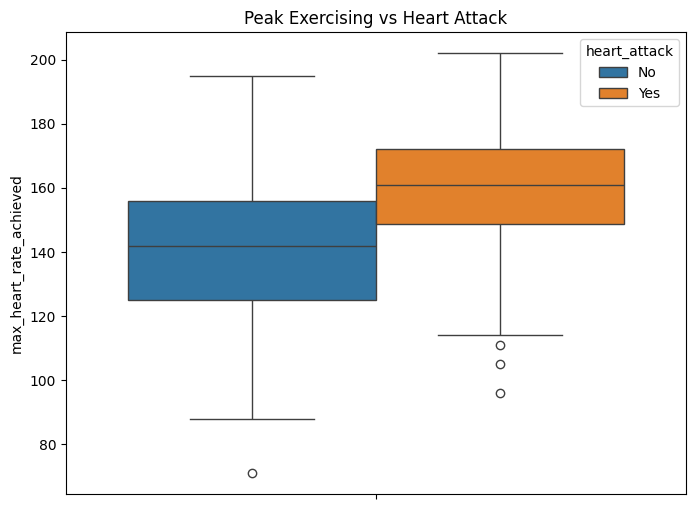

In [55]:
# g. Peak Exercise (e.g., thalach) vs Heart Attack
plt.figure(figsize=(8,6))
sns.boxplot(y ='max_heart_rate_achieved',hue='heart_attack', data =data)
plt.title('Peak Exercising vs Heart Attack')
plt.show()

The boxplot shows that people who had a heart attack usually reached a higher maximum heart rate than those who didn’t. But this doesn’t mean that a high heart rate causes heart attacks. Here’s why:
- It could be from exercise or stress tests, where heart rate naturally goes up.
- Younger or fitter people can reach higher heart rates safely.
- Heart rate might be measured during an emergency, like a heart attack, which naturally pushes it higher.

Low Heart Rate Outliers: The presence of individuals with very low maximum heart rates in both groups highlights another important nuance. While a low heart rate is often associated with good cardiovascular fitness, in some cases it may reflect underlying issues such as: poor fitness or blocked arteries, which are also risky.

Conclusion:
Maximum heart rate should not be used alone to assess heart attack risk. It is more meaningful when combined with other factors like age, blood pressure, ECG results, and medical history.

<Axes: xlabel='thalassemia_type', ylabel='count'>

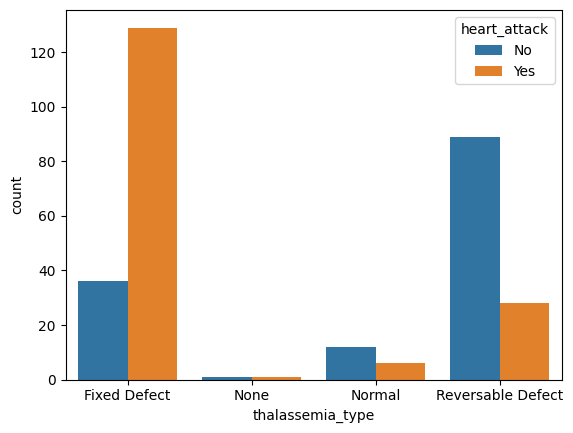

In [56]:
# h. Thalassemia (thal) as a Cause
sns.countplot(x='thalassemia_type', hue = 'heart_attack', data=data)

- Fixed defect type of thalassemia is strongly associated with heart attacks.
- People with normal or reversible types seem less likely to have heart attacks.
- Having no thalassemia doesn't clearly impact risk, since both groups are similar.

Conclusion:
Thalassemia type, especially fixed defect, could be a significant factor when assessing heart attack risk and should be considered in diagnosis or prediction models.


<Axes: xlabel='st_slope', ylabel='count'>

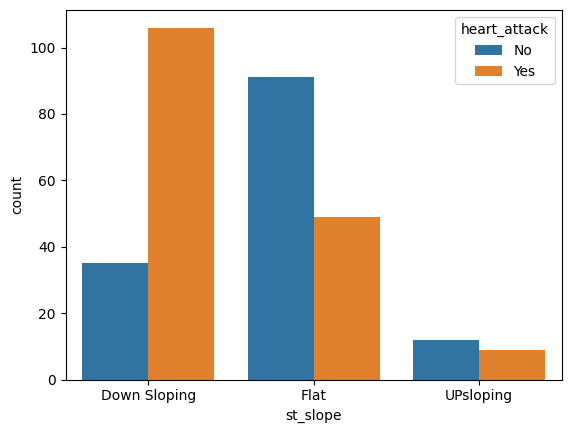

In [57]:
sns.countplot(x='st_slope', hue = 'heart_attack', data=data)

Observation:
- Downsloping ST slope is the most risky and highly associated with heart attacks in this case.
- Flat slope is more common in people without heart attacks but can still carry some risk.
- Upsloping appears safest, with most individuals not experiencing heart attack but very close to "yes" plot so still needs to be considered.

Medically, downsloping ST segments often indicate ischemia or serious heart issues, so this aligns with clinical knowledge also.

#### Let's create a correlation heatmap:
- Step 1: Identify categorical features:
since, i've already created a variable with all categorical columns, named cat_features, i can proceed with Step 2.

In [58]:
# Step 2: Encode categorical features as numeric if needed
data_encoded = data[cat_features].copy()
for col in cat_features:
    data_encoded[col] = data_encoded[col].astype('category').cat.codes

# Step 3: Calculate correlation matrix
corr_matrix = data_encoded.corr()

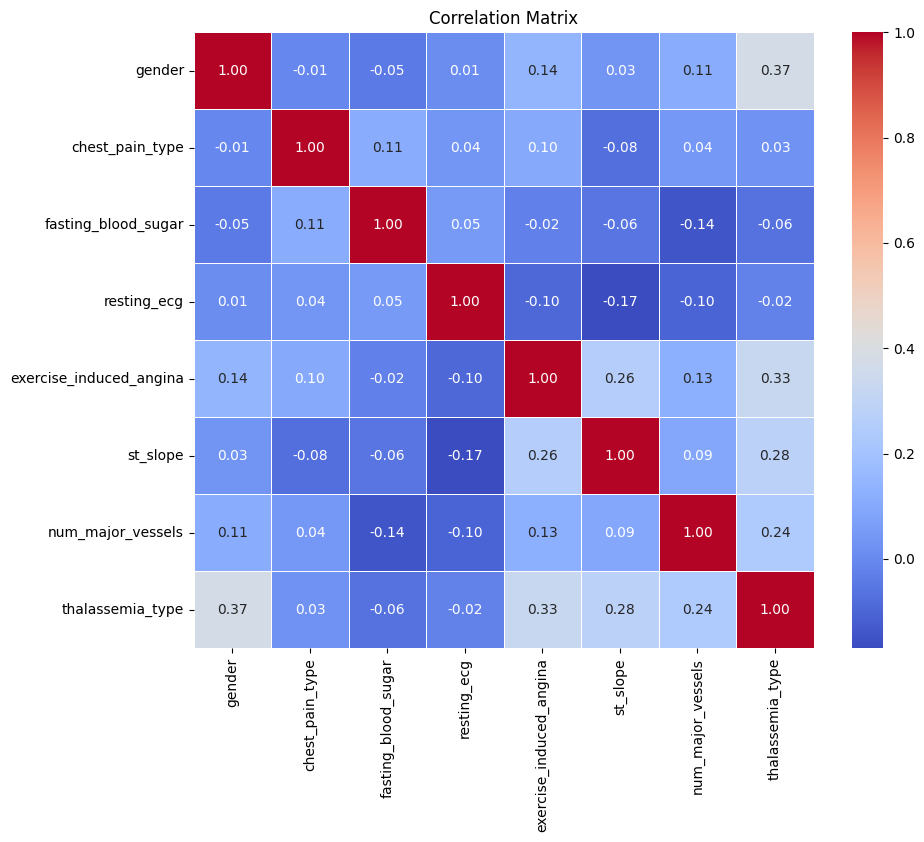

In [59]:
# Step 4. Visualize the correlation matrix using a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()


Values close to 0 (like -0.01, -0.02, +0.10, etc.): these show almost no relationship between the variables. The variables are not clearly moving together in any direction.
Small positive values (like +0.13, +0.18, +0.24, +0.33): these show a weak positive correlation. 
Example: If cholesterol and heart attack have a correlation of +0.24, higher cholesterol might be slightly linked with heart attack — but it’s not strong.

Small negative values (like -0.10, -0.07, -0.05): these show a weak negative correlation. 
Example: If age and max heart rate show -0.10, older people might slightly have lower max heart rate, but again, not strongly.

# 2.	Build a baseline model to predict using a Logistic Regression and explore the results.

A baseline logistic regression model is built after completing data cleaning and exploratory analysis, to provide an initial benchmark for model performance and assess how well basic health indicators could predict heart attack risk. 

Since, in my dataset, I have both categorical and numerical features, I need to handle each type of feature appropriately before feeding the data into a machine learning model like Logistic Regression.
The Steps that I followed to accomplish this task are the following:

In [60]:
# Step 1: Split Features and Targets
X = data.drop('heart_attack', axis=1)  
y = data['heart_attack']

In [61]:
# Step 2: Identify Column Types
categorical_cols = X.select_dtypes(include=['object', 'category']).columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

In [62]:
# Step 3: Preprocessing Pipelines
from sklearn.compose import ColumnTransformer   # use column transformer to process columns differently based on type
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [63]:
# Step 4: Define Preprocessing Steps

# One-hot encode categorical data
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

# Scale numerical data
numerical_transformer = StandardScaler()

# Combine both using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

In [64]:
# Step 5: Build Pipeline with Logistic Regression
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

In [65]:
# Step 6: Train-Test Split and Fit
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['age', 'resting_blood_pressure', 'cholesterol',
       'max_heart_rate_achieved', 'st_depression', 'num_major_vessels'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['gender', 'chest_pain_type', 'fasting_blood_sugar', 'resting_ecg',
       'exercise_induced_angina', 'st_slope', 'thalassemia_type', 'age_bin'],
      dtype='object'))])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [66]:
# Step 7: Evaluate the Model and Heatmap chart
from sklearn.metrics import classification_report, confusion_matrix
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

          No       0.84      0.90      0.87        29
         Yes       0.90      0.84      0.87        32

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61



Observation:
The model is performing quite well with 87% overall accuracy, and the F1-scores for both classes ("Yes", "No") indicates a good balance between precision and recall.

Recall is higher for the "NO" class, meaning the model is better at identifying cases whether there is no heart attack. On the other hand, precision is higher for "Yes", meaning the model is better at avoiding false positives (incorrectly predicting a heart attack when there is none).

# Conclusion: Heart Attack Prediction — Feature Analysis
Based on the correlation analysis, no single variable (e.g., age, cholesterol, blood pressure) shows a strong individual correlation with heart attack outcome.
Most variables have weak correlations, meaning they are not powerful predictors on their own. Weak correlations do not mean the variables are useless — they may still work well in combination.

Features like chest pain type (Non-anginal Pain), ST slope (Down Sloping), thalassemia type (Fixed Defect), and exercise-induced angina show stronger differences between heart attack and non-heart attack groups when viewed through plots and confusion matrices — even if correlation is low.
